# Bank Churners Dataset Analysis

This notebook performs cleaning and classification using Logistic Regression, Random Forest, and XGBoost.

In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, r2_score


# Load data
df = pd.read_csv("BankChurners.csv")

# Drop unnecessary columns
df_cleaned = df.drop(columns=["CLIENTNUM"] + [col for col in df.columns if "Naive_Bayes" in col])
df_cleaned = df_cleaned.dropna()

# Encode categorical variables
label_encoders = {}
for col in df_cleaned.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

# Define features and target
X = df_cleaned.drop(columns=["Attrition_Flag"])
y = df_cleaned["Attrition_Flag"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression
[[ 154  173]
 [  60 1639]]
              precision    recall  f1-score   support

           0       0.72      0.47      0.57       327
           1       0.90      0.96      0.93      1699

    accuracy                           0.88      2026
   macro avg       0.81      0.72      0.75      2026
weighted avg       0.87      0.88      0.87      2026



/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [3]:

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression
[[ 178  149]
 [  52 1647]]
              precision    recall  f1-score   support

           0       0.77      0.54      0.64       327
           1       0.92      0.97      0.94      1699

    accuracy                           0.90      2026
   macro avg       0.85      0.76      0.79      2026
weighted avg       0.89      0.90      0.89      2026



In [4]:
coefs = np.abs(lr.coef_[0])
feature_names = X_train.columns
lr_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefs
}).sort_values(by="Importance", ascending=False)
print("Logistic Regression Feature Importance:\n", lr_importance)

Logistic Regression Feature Importance:
                      Feature  Importance
16            Total_Trans_Ct    2.678992
15           Total_Trans_Amt    1.546305
12       Total_Revolving_Bal    0.728131
8   Total_Relationship_Count    0.691129
17       Total_Ct_Chng_Q4_Q1    0.656991
10     Contacts_Count_12_mon    0.575311
9     Months_Inactive_12_mon    0.519103
1                     Gender    0.349230
2            Dependent_count    0.175603
4             Marital_Status    0.144895
7             Months_on_book    0.106128
14      Total_Amt_Chng_Q4_Q1    0.094758
3            Education_Level    0.067372
18     Avg_Utilization_Ratio    0.056594
0               Customer_Age    0.045789
11              Credit_Limit    0.034441
13           Avg_Open_To_Buy    0.030929
6              Card_Category    0.027647
5            Income_Category    0.026777


In [5]:
# Use probabilities instead of class labels
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
r2 = r2_score(y_test, y_prob)
print("R² Score:", r2)

R² Score: 0.4537653031805112


In [6]:

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Classifier")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier
[[ 264   63]
 [  25 1674]]
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       327
           1       0.96      0.99      0.97      1699

    accuracy                           0.96      2026
   macro avg       0.94      0.90      0.92      2026
weighted avg       0.96      0.96      0.96      2026



In [7]:
importances = rf.feature_importances_
feature_names = X_train.columns
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
print("Random Forest Feature Importance:\n", rf_importance)

Random Forest Feature Importance:
                      Feature  Importance
15           Total_Trans_Amt    0.191815
16            Total_Trans_Ct    0.167532
17       Total_Ct_Chng_Q4_Q1    0.113850
12       Total_Revolving_Bal    0.098322
18     Avg_Utilization_Ratio    0.067355
8   Total_Relationship_Count    0.066259
14      Total_Amt_Chng_Q4_Q1    0.061835
11              Credit_Limit    0.035185
0               Customer_Age    0.031245
13           Avg_Open_To_Buy    0.031187
9     Months_Inactive_12_mon    0.026805
10     Contacts_Count_12_mon    0.026209
7             Months_on_book    0.025717
2            Dependent_count    0.013081
3            Education_Level    0.011204
1                     Gender    0.011019
5            Income_Category    0.010754
4             Marital_Status    0.008560
6              Card_Category    0.002068


In [8]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)

ROC AUC Score: 0.9888457502434423


In [9]:

xgb = XGBClassifier(eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Classifier")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Classifier
[[ 289   38]
 [  34 1665]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       327
           1       0.98      0.98      0.98      1699

    accuracy                           0.96      2026
   macro avg       0.94      0.93      0.93      2026
weighted avg       0.96      0.96      0.96      2026



In [10]:
# Get feature importances
importances = xgb.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Display top features
print(importance_df)

                     Feature  Importance
16            Total_Trans_Ct    0.260542
12       Total_Revolving_Bal    0.183848
8   Total_Relationship_Count    0.130741
15           Total_Trans_Amt    0.067764
17       Total_Ct_Chng_Q4_Q1    0.046268
9     Months_Inactive_12_mon    0.043043
0               Customer_Age    0.041676
1                     Gender    0.041529
10     Contacts_Count_12_mon    0.036454
14      Total_Amt_Chng_Q4_Q1    0.030257
11              Credit_Limit    0.028617
13           Avg_Open_To_Buy    0.016707
2            Dependent_count    0.014160
7             Months_on_book    0.011594
4             Marital_Status    0.011528
18     Avg_Utilization_Ratio    0.011481
3            Education_Level    0.008655
6              Card_Category    0.007944
5            Income_Category    0.007192


In [11]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)

ROC AUC Score: 0.9921756456847254


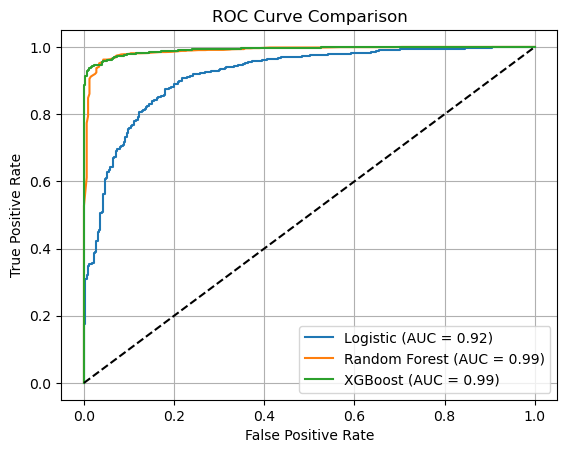

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Predict probabilities
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]  # Logistic Regression (scaled)
rf_probs = rf.predict_proba(X_test)[:, 1]         # Random Forest (no scaling)
xgb_probs = xgb.predict_proba(X_test)[:, 1]       # XGBoost (no scaling)

# Calculate ROC curve and AUC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Plot
plt.figure()
plt.plot(lr_fpr, lr_tpr, label=f'Logistic (AUC = {lr_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal (random)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

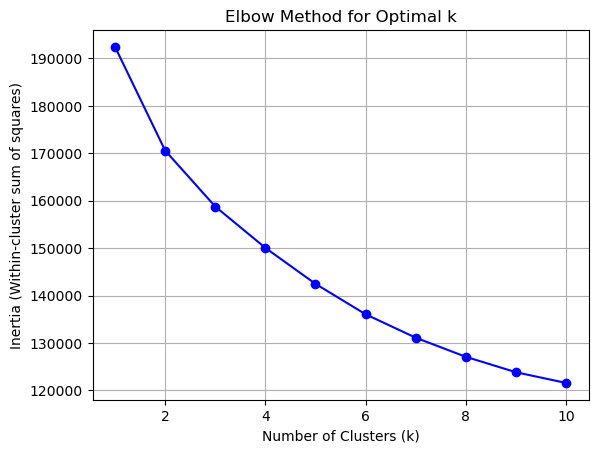

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate inertia for different k values
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure()
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

[3.35607386e+00 1.40850070e+01 3.65282519e+00 3.12006900e-01
 3.50308488e+00 3.13154589e+00 3.69161228e-01 1.89707057e+00
 2.33072886e+02 2.40910376e+02 4.41868050e+02 5.77372937e+00
 7.52702408e+02 8.22850487e-04 1.76961638e+02 2.96227714e+02
 1.62012169e+03 9.30078416e+02 3.32876795e+02]


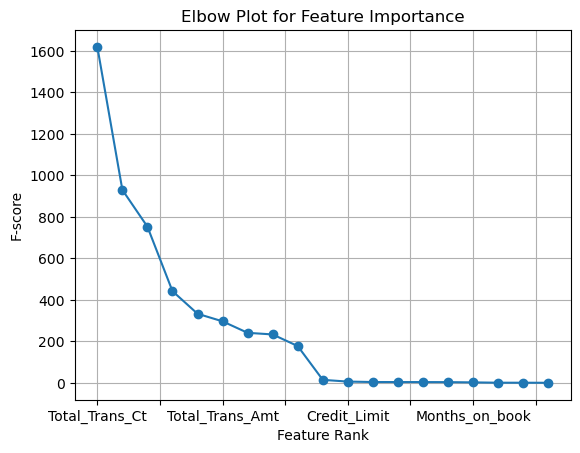

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import pandas as pd

# Get feature scores
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)
scores = selector.scores_
print(scores)

# Plot elbow-style feature importance
features = pd.Series(scores, index=X.columns).sort_values(ascending=False)

plt.figure()
features.plot(kind='line', marker='o')
plt.ylabel('F-score')
plt.xlabel('Feature Rank')
plt.title('Elbow Plot for Feature Importance')
plt.grid(True)
plt.show()